# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print("=== df_fatalities ===")
print("Shape:", df_fatalities.shape)
print("Columns:", df_fatalities.columns.tolist())
df_fatalities.head()

=== df_fatalities ===
Shape: (2535, 14)
Columns: ['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [6]:
print("=== df_hh_income ===")
print("Shape:", df_hh_income.shape)
print("Columns:", df_hh_income.columns.tolist())
print()
print("=== df_pct_poverty ===")
print("Shape:", df_pct_poverty.shape)
print("Columns:", df_pct_poverty.columns.tolist())
print()
print("=== df_pct_completed_hs ===")
print("Shape:", df_pct_completed_hs.shape)
print("Columns:", df_pct_completed_hs.columns.tolist())
print()
print("=== df_share_race_city ===")
print("Shape:", df_share_race_city.shape)
print("Columns:", df_share_race_city.columns.tolist())

=== df_hh_income ===
Shape: (29322, 3)
Columns: ['Geographic Area', 'City', 'Median Income']

=== df_pct_poverty ===
Shape: (29329, 3)
Columns: ['Geographic Area', 'City', 'poverty_rate']

=== df_pct_completed_hs ===
Shape: (29329, 3)
Columns: ['Geographic Area', 'City', 'percent_completed_hs']

=== df_share_race_city ===
Shape: (29268, 7)
Columns: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']


In [7]:
print("=== NaN Values ===")
print("df_fatalities:\n", df_fatalities.isnull().sum())
print("\ndf_hh_income:\n", df_hh_income.isnull().sum())
print("\ndf_pct_poverty:\n", df_pct_poverty.isnull().sum())
print("\ndf_pct_completed_hs:\n", df_pct_completed_hs.isnull().sum())
print("\ndf_share_race_city:\n", df_share_race_city.isnull().sum())
print()
print("=== Duplicates ===")
print("df_fatalities:", df_fatalities.duplicated().sum())
print("df_hh_income:", df_hh_income.duplicated().sum())
print("df_pct_poverty:", df_pct_poverty.duplicated().sum())
print("df_pct_completed_hs:", df_pct_completed_hs.duplicated().sum())
print("df_share_race_city:", df_share_race_city.duplicated().sum())

=== NaN Values ===
df_fatalities:
 id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

df_hh_income:
 Geographic Area     0
City                0
Median Income      51
dtype: int64

df_pct_poverty:
 Geographic Area    0
City               0
poverty_rate       0
dtype: int64

df_pct_completed_hs:
 Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

df_share_race_city:
 Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtyp

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [8]:
# Convert string columns to numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
for col in ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

print("Conversion complete.")

Conversion complete.


In [9]:
# Fill NaN values with 0 where appropriate
df_pct_poverty.fillna(0, inplace=True)
df_pct_completed_hs.fillna(0, inplace=True)
df_share_race_city.fillna(0, inplace=True)
df_hh_income.fillna(0, inplace=True)

print("NaN values remaining in df_pct_poverty:", df_pct_poverty.isnull().sum().sum())
print("NaN values remaining in df_pct_completed_hs:", df_pct_completed_hs.isnull().sum().sum())
print("NaN values remaining in df_share_race_city:", df_share_race_city.isnull().sum().sum())
print("NaN values remaining in df_hh_income:", df_hh_income.isnull().sum().sum())
print("\nNote: df_fatalities NaN values left as-is (handled per chart)")
print("df_fatalities NaN counts:\n", df_fatalities.isnull().sum())

NaN values remaining in df_pct_poverty: 0
NaN values remaining in df_pct_completed_hs: 0
NaN values remaining in df_share_race_city: 0
NaN values remaining in df_hh_income: 0

Note: df_fatalities NaN values left as-is (handled per chart)
df_fatalities NaN counts:
 id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [10]:
poverty_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
poverty_by_state = poverty_by_state.sort_values('poverty_rate', ascending=False)

fig = px.bar(
    poverty_by_state,
    x='Geographic Area',
    y='poverty_rate',
    title='Poverty Rate by US State (Highest to Lowest)',
    labels={'Geographic Area': 'State', 'poverty_rate': 'Poverty Rate (%)'},
    color='poverty_rate',
    color_continuous_scale='reds'
)
fig.show()

In [11]:
print(f"Highest poverty rate: {poverty_by_state.iloc[0]['Geographic Area']} "
      f"({poverty_by_state.iloc[0]['poverty_rate']:.1f}%)")
print(f"Lowest poverty rate:  {poverty_by_state.iloc[-1]['Geographic Area']} "
      f"({poverty_by_state.iloc[-1]['poverty_rate']:.1f}%)")

Highest poverty rate: MS (26.9%)
Lowest poverty rate:  NJ (8.2%)


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [12]:
hs_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()
hs_by_state = hs_by_state.sort_values('percent_completed_hs', ascending=True)

fig = px.bar(
    hs_by_state,
    x='Geographic Area',
    y='percent_completed_hs',
    title='High School Graduation Rate by US State (Lowest to Highest)',
    labels={'Geographic Area': 'State', 'percent_completed_hs': 'HS Graduation Rate (%)'},
    color='percent_completed_hs',
    color_continuous_scale='blues'
)
fig.show()

print(f"Lowest HS graduation rate:  {hs_by_state.iloc[0]['Geographic Area']} "
      f"({hs_by_state.iloc[0]['percent_completed_hs']:.1f}%)")
print(f"Highest HS graduation rate: {hs_by_state.iloc[-1]['Geographic Area']} "
      f"({hs_by_state.iloc[-1]['percent_completed_hs']:.1f}%)")

Lowest HS graduation rate:  TX (74.1%)
Highest HS graduation rate: MA (92.0%)


# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [13]:
import plotly.graph_objects as go

# Merge poverty and HS data by state, sorted by poverty rate descending
merged = pd.merge(poverty_by_state, hs_by_state, on='Geographic Area')
merged = merged.sort_values('poverty_rate', ascending=False)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged['Geographic Area'],
    y=merged['poverty_rate'],
    name='Poverty Rate (%)',
    yaxis='y1',
    mode='lines+markers',
    line=dict(color='red')
))

fig.add_trace(go.Scatter(
    x=merged['Geographic Area'],
    y=merged['percent_completed_hs'],
    name='HS Graduation Rate (%)',
    yaxis='y2',
    mode='lines+markers',
    line=dict(color='blue')
))

fig.update_layout(
    title='Poverty Rate vs High School Graduation Rate by State',
    xaxis=dict(title='State', tickangle=45),
    yaxis=dict(title='Poverty Rate (%)', color='red'),
    yaxis2=dict(title='HS Graduation Rate (%)', overlaying='y', side='right', color='blue'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()

In [14]:
# The chart reveals an inverse relationship: states with higher poverty rates 
# tend to have lower high school graduation rates, and vice versa.
print("Correlation between poverty rate and HS graduation rate:")
print(f"{merged['poverty_rate'].corr(merged['percent_completed_hs']):.3f}")
print("\nNegative correlation confirms: higher poverty → lower graduation rates.")

Correlation between poverty rate and HS graduation rate:
-0.806

Negative correlation confirms: higher poverty → lower graduation rates.


#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

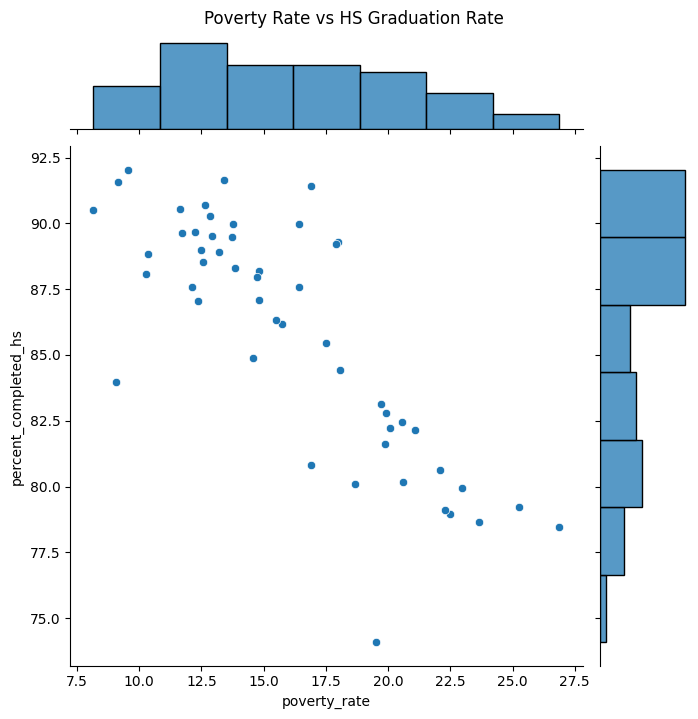

In [15]:
sns.jointplot(
    x='poverty_rate',
    y='percent_completed_hs',
    data=merged,
    kind='scatter',
    height=7
)
plt.suptitle('Poverty Rate vs HS Graduation Rate', y=1.02)
plt.show()

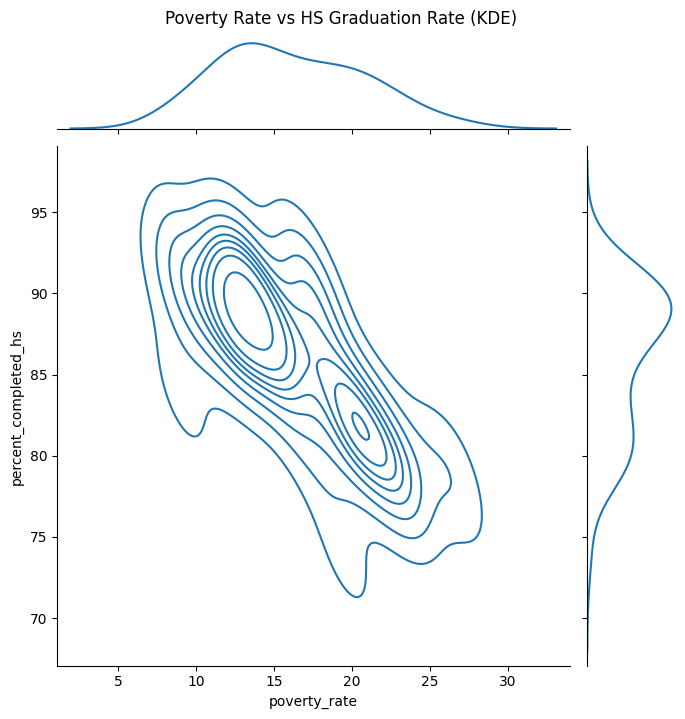

In [16]:
sns.jointplot(
    x='poverty_rate',
    y='percent_completed_hs',
    data=merged,
    kind='kde',
    height=7
)
plt.suptitle('Poverty Rate vs HS Graduation Rate (KDE)', y=1.02)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

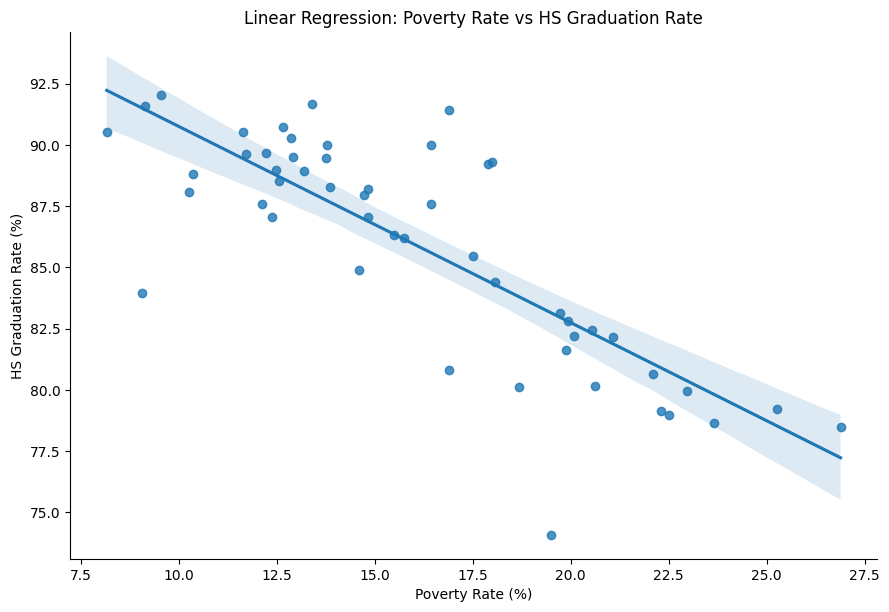

In [17]:
sns.lmplot(
    x='poverty_rate',
    y='percent_completed_hs',
    data=merged,
    height=6,
    aspect=1.5
)
plt.title('Linear Regression: Poverty Rate vs HS Graduation Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('HS Graduation Rate (%)')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [18]:
race_by_state = df_share_race_city.groupby('Geographic area')[
    ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
].mean().reset_index()

race_by_state_melted = race_by_state.melt(
    id_vars='Geographic area',
    var_name='Race',
    value_name='Share'
)

race_label_map = {
    'share_white': 'White',
    'share_black': 'Black',
    'share_native_american': 'Native American',
    'share_asian': 'Asian',
    'share_hispanic': 'Hispanic'
}
race_by_state_melted['Race'] = race_by_state_melted['Race'].map(race_label_map)

fig = px.bar(
    race_by_state_melted,
    x='Geographic area',
    y='Share',
    color='Race',
    title='Racial Makeup of Each US State',
    labels={'Geographic area': 'State', 'Share': 'Population Share (%)'},
    barmode='stack'
)
fig.show()

In [19]:
# Most diverse vs. least diverse states
race_by_state['max_share'] = race_by_state[
    ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
].max(axis=1)
print("Most racially diverse states (lowest dominant-race share):")
print(race_by_state.nsmallest(5, 'max_share')[['Geographic area', 'max_share']].to_string(index=False))

Most racially diverse states (lowest dominant-race share):
Geographic area  max_share
             HI      33.37
             AK      45.48
             DC      50.70
             MS      53.80
             AZ      59.93


# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [20]:
race_killed = df_fatalities['race'].value_counts().reset_index()
race_killed.columns = ['race', 'count']

race_labels_dict = {
    'W': 'White', 'B': 'Black', 'H': 'Hispanic',
    'A': 'Asian', 'N': 'Native American', 'O': 'Other'
}
race_killed['race'] = race_killed['race'].map(race_labels_dict).fillna('Unknown')

fig = px.pie(
    race_killed,
    values='count',
    names='race',
    hole=0.4,
    title='People Killed by Police by Race'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [21]:
print("Breakdown of people killed by police by race:")
print(race_killed.to_string(index=False))

Breakdown of people killed by police by race:
           race  count
          White   1201
          Black    618
       Hispanic    423
          Asian     39
Native American     31
          Other     28


# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [22]:
gender_counts = df_fatalities['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']
gender_counts['gender'] = gender_counts['gender'].map({'M': 'Male', 'F': 'Female'})

fig = px.bar(
    gender_counts,
    x='gender',
    y='count',
    color='gender',
    title='Total Police Killings by Gender',
    labels={'gender': 'Gender', 'count': 'Number of Deaths'},
    color_discrete_map={'Male': 'steelblue', 'Female': 'salmon'}
)
fig.show()

In [23]:
male = gender_counts[gender_counts['gender'] == 'Male']['count'].values[0]
female = gender_counts[gender_counts['gender'] == 'Female']['count'].values[0]
print(f"Men killed:   {male:,} ({male / (male + female) * 100:.1f}%)")
print(f"Women killed: {female:,} ({female / (male + female) * 100:.1f}%)")
print(f"Men are killed {male / female:.0f}x more often than women.")

Men killed:   2,428 (95.8%)
Women killed: 107 (4.2%)
Men are killed 23x more often than women.


# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [24]:
df_fatalities_clean = df_fatalities.dropna(subset=['age']).copy()
df_fatalities_clean['gender_label'] = df_fatalities_clean['gender'].map({'M': 'Male', 'F': 'Female'})

fig = px.box(
    df_fatalities_clean,
    x='manner_of_death',
    y='age',
    color='gender_label',
    title='Age Distribution by Manner of Death and Gender',
    labels={
        'manner_of_death': 'Manner of Death',
        'age': 'Age',
        'gender_label': 'Gender'
    },
    color_discrete_map={'Male': 'steelblue', 'Female': 'salmon'}
)
fig.show()

In [25]:
print("Median age by manner of death and gender:")
print(df_fatalities_clean.groupby(['manner_of_death', 'gender_label'])['age'].median().unstack())

Median age by manner of death and gender:
gender_label      Female  Male
manner_of_death               
shot               36.00 34.00
shot and Tasered   37.00 35.00


In [26]:
# The box plots show that women tend to be slightly older than men at the time of death.
# Both genders show similar age distributions across manner-of-death categories.
print("The box plots indicate women killed by police tend to be slightly older than men.")
print("There is no dramatic difference in manner-of-death between genders.")

The box plots indicate women killed by police tend to be slightly older than men.
There is no dramatic difference in manner-of-death between genders.


# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [27]:
total = len(df_fatalities)
unarmed_count = (df_fatalities['armed'] == 'unarmed').sum()
armed_count = total - df_fatalities['armed'].isna().sum() - unarmed_count

print(f"Total killings: {total:,}")
print(f"Unarmed:        {unarmed_count:,} ({unarmed_count / total * 100:.1f}%)")
print(f"Armed:          {armed_count:,} ({armed_count / total * 100:.1f}%)")

Total killings: 2,535
Unarmed:        171 (6.7%)
Armed:          2,355 (92.9%)


In [28]:
weapon_counts = df_fatalities['armed'].value_counts().reset_index()
weapon_counts.columns = ['weapon', 'count']

fig = px.bar(
    weapon_counts.head(15),
    x='weapon',
    y='count',
    title='Type of Weapon Carried by Deceased (Top 15)',
    labels={'weapon': 'Weapon', 'count': 'Number of Killings'},
    color='count',
    color_continuous_scale='oranges'
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [29]:
gun_count = (df_fatalities['armed'] == 'gun').sum()

fig = px.bar(
    x=['Armed with Gun', 'Unarmed'],
    y=[gun_count, unarmed_count],
    title='Armed with Gun vs Unarmed at Time of Killing',
    labels={'x': 'Category', 'y': 'Number of Deaths'},
    color=['Armed with Gun', 'Unarmed'],
    color_discrete_map={'Armed with Gun': 'crimson', 'Unarmed': 'steelblue'}
)
fig.show()

print(f"Armed with gun: {gun_count:,} ({gun_count / total * 100:.1f}%)")
print(f"Unarmed:        {unarmed_count:,} ({unarmed_count / total * 100:.1f}%)")
print(f"\nPeople armed with guns are killed {gun_count // unarmed_count}x more often than unarmed people.")

Armed with gun: 1,398 (55.1%)
Unarmed:        171 (6.7%)

People armed with guns are killed 8x more often than unarmed people.


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [30]:
df_with_age = df_fatalities.dropna(subset=['age'])
under_25 = (df_with_age['age'] < 25).sum()
pct_under_25 = under_25 / len(df_with_age) * 100

print(f"Total with known age: {len(df_with_age):,}")
print(f"Under 25 years old:   {under_25:,} ({pct_under_25:.1f}%)")

Total with known age: 2,458
Under 25 years old:   450 (18.3%)


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

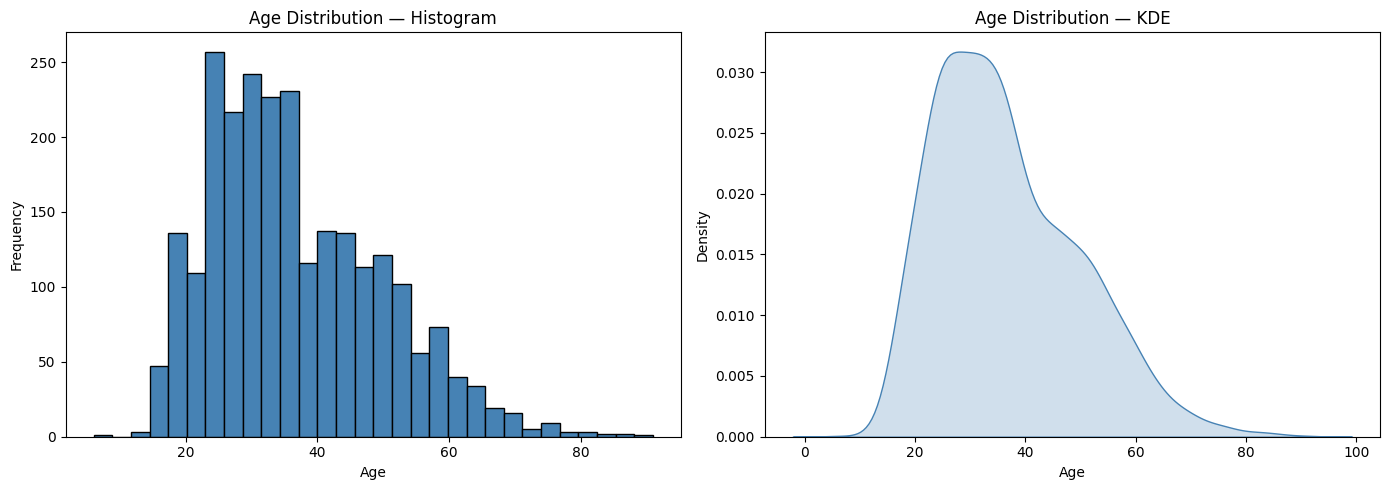

Mean age:   36.6
Median age: 34.0


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_with_age['age'], bins=30, edgecolor='black', color='steelblue')
axes[0].set_title('Age Distribution — Histogram')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# KDE
sns.kdeplot(df_with_age['age'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Age Distribution — KDE')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

print(f"Mean age:   {df_with_age['age'].mean():.1f}")
print(f"Median age: {df_with_age['age'].median():.1f}")

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

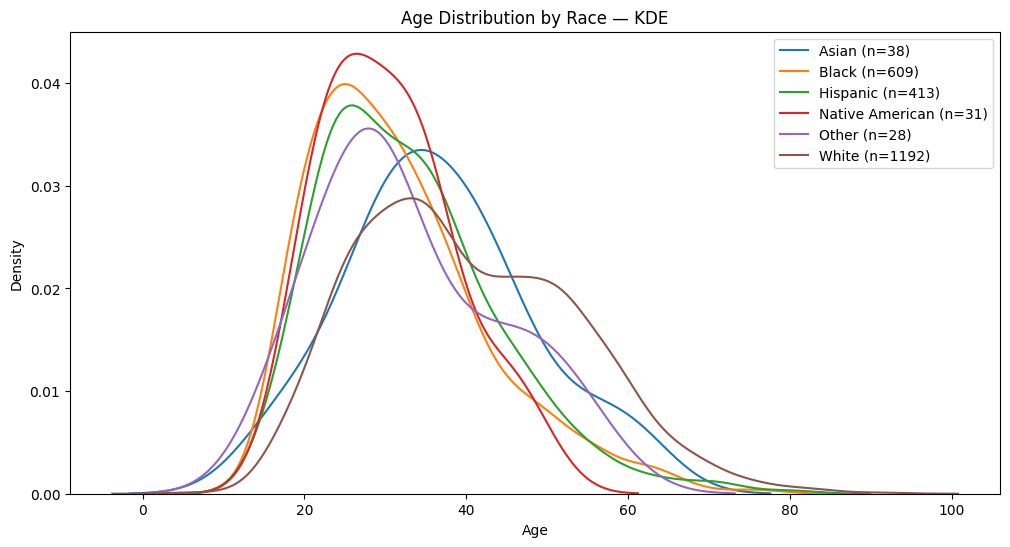

Median age at time of death by race:
race_label
Native American   29.00
Other             29.50
Black             30.00
Hispanic          31.00
Asian             35.00
White             38.00
Name: age, dtype: float64


In [32]:
df_age_race = df_fatalities.dropna(subset=['age', 'race']).copy()
df_age_race['race_label'] = df_age_race['race'].map(race_labels_dict)

plt.figure(figsize=(12, 6))
for race in sorted(df_age_race['race_label'].dropna().unique()):
    subset = df_age_race[df_age_race['race_label'] == race]
    sns.kdeplot(subset['age'], label=f"{race} (n={len(subset)})", fill=False)

plt.title('Age Distribution by Race — KDE')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

print("Median age at time of death by race:")
print(df_age_race.groupby('race_label')['age'].median().sort_values())

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [33]:
race_bar = df_fatalities['race'].value_counts().reset_index()
race_bar.columns = ['race', 'count']
race_bar['race'] = race_bar['race'].map(race_labels_dict).fillna('Unknown')
race_bar = race_bar.sort_values('count', ascending=False)

fig = px.bar(
    race_bar,
    x='race',
    y='count',
    color='race',
    title='Total People Killed by Police by Race',
    labels={'race': 'Race', 'count': 'Number of Deaths'}
)
fig.show()

In [34]:
print("Note: Raw counts favour White victims simply due to population size.")
print("Black Americans (~13% of US population) make up a disproportionately high share of killings.")
print(race_bar.to_string(index=False))

Note: Raw counts favour White victims simply due to population size.
Black Americans (~13% of US population) make up a disproportionately high share of killings.
           race  count
          White   1201
          Black    618
       Hispanic    423
          Asian     39
Native American     31
          Other     28


In [35]:
# Per-capita killing rate by race
# Source: 2015 US Census Bureau population estimates by race
us_population_by_race = {
    'White':           196_817_552,
    'Black':            40_241_818,
    'Hispanic':         57_470_446,
    'Asian':            18_004_981,
    'Native American':   2_572_898,
    'Other':             8_000_000,
}

rate_rows = []
for _, row in race_bar.iterrows():
    race = row['race']
    kills = row['count']
    pop = us_population_by_race.get(race)
    if pop:
        rate_rows.append({
            'race': race,
            'kills': kills,
            'population': pop,
            'rate_per_million': (kills / pop) * 1_000_000
        })

df_rate = pd.DataFrame(rate_rows).sort_values('rate_per_million', ascending=False)

fig = px.bar(
    df_rate,
    x='race',
    y='rate_per_million',
    color='race',
    title='Police Killings per Million People by Race (2015 US Census baseline)',
    labels={'race': 'Race', 'rate_per_million': 'Killings per Million People'}
)
fig.show()

white_rate = df_rate[df_rate['race'] == 'White']['rate_per_million'].values[0]
black_rate = df_rate[df_rate['race'] == 'Black']['rate_per_million'].values[0]

print("Killing rate per million people by race:")
for _, row in df_rate.iterrows():
    print(f"  {row['race']:<18} {row['rate_per_million']:>6.1f} per million")

print(f"\nBlack Americans are killed at {black_rate / white_rate:.1f}x the rate of White Americans.")


Killing rate per million people by race:
  Black                15.4 per million
  Native American      12.0 per million
  Hispanic              7.4 per million
  White                 6.1 per million
  Other                 3.5 per million
  Asian                 2.2 per million

Black Americans are killed at 2.5x the rate of White Americans.


# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [36]:
mental_illness_counts = df_fatalities['signs_of_mental_illness'].value_counts()
pct_mental = mental_illness_counts[True] / len(df_fatalities) * 100

print(f"With signs of mental illness:    {mental_illness_counts[True]:,} ({pct_mental:.1f}%)")
print(f"Without signs of mental illness: {mental_illness_counts[False]:,} ({100 - pct_mental:.1f}%)")

With signs of mental illness:    633 (25.0%)
Without signs of mental illness: 1,902 (75.0%)


In [37]:
fig = px.pie(
    values=mental_illness_counts.values,
    names=['No Mental Illness', 'Mental Illness'],
    hole=0.4,
    title='Signs of Mental Illness Among Police Killing Victims',
    color_discrete_sequence=['steelblue', 'crimson']
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [38]:
top10_cities = df_fatalities['city'].value_counts().head(10).reset_index()
top10_cities.columns = ['city', 'killings']

fig = px.bar(
    top10_cities,
    x='city',
    y='killings',
    title='Top 10 Cities with Most Police Killings',
    labels={'city': 'City', 'killings': 'Number of Killings'},
    color='killings',
    color_continuous_scale='reds'
)
fig.show()

In [39]:
print("Top 10 most dangerous cities for police killings:")
print(top10_cities.to_string(index=False))

Top 10 most dangerous cities for police killings:
       city  killings
Los Angeles        39
    Phoenix        31
    Houston        27
    Chicago        25
  Las Vegas        21
San Antonio        20
   Columbus        19
     Austin        18
      Miami        18
  St. Louis        15


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [40]:
top10_city_names = top10_cities['city'].tolist()

# Killings by race in top 10 cities
fatalities_top10 = df_fatalities[df_fatalities['city'].isin(top10_city_names)].copy()
fatalities_top10['race_label'] = fatalities_top10['race'].map(race_labels_dict).fillna('Unknown')

kill_by_race = fatalities_top10.groupby(['city', 'race_label']).size().reset_index(name='kills')
total_by_city = fatalities_top10.groupby('city').size().reset_index(name='total')
kill_by_race = kill_by_race.merge(total_by_city, on='city')
kill_by_race['kill_pct'] = kill_by_race['kills'] / kill_by_race['total'] * 100

fig = px.bar(
    kill_by_race,
    x='city',
    y='kill_pct',
    color='race_label',
    title='Share of Police Killings by Race in Top 10 Cities',
    labels={'city': 'City', 'kill_pct': '% of Killings', 'race_label': 'Race'},
    barmode='stack'
)
fig.show()

In [41]:
# Contrast kill share with population share in those cities
# Match city names (fatalities uses city names, race uses City column)
race_top10 = df_share_race_city[df_share_race_city['City'].str.replace(' city', '').str.replace(' CDP', '').isin(top10_city_names)].copy()
race_top10_agg = race_top10.groupby('City')[
    ['share_white', 'share_black', 'share_hispanic', 'share_asian', 'share_native_american']
].mean()

print("Average racial population share in cities matching top 10 (approximate):")
print(race_top10_agg.to_string())
print("\nCompare these population shares against the kill percentages in the chart above.")
print("Disproportionately high kill % relative to population share indicates over-representation.")

Average racial population share in cities matching top 10 (approximate):
                  share_white  share_black  share_hispanic  share_asian  share_native_american
City                                                                                          
Austin CDP              95.80         0.00            9.40         0.50                   0.50
Austin city             86.60         3.35           14.23         2.33                   0.45
Chicago city            45.00        32.90           28.90         5.50                   0.50
Columbus CDP            98.80         0.00            0.20         0.20                   0.00
Columbus city           76.56        15.77            6.24         1.85                   0.62
Houston city            75.90        13.14           11.12         1.54                   1.70
Las Vegas city          63.50         6.50           56.00         3.50                   1.40
Los Angeles CDP         63.60         9.10          100.00         0.00 

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [42]:
killings_by_state = df_fatalities['state'].value_counts().reset_index()
killings_by_state.columns = ['state', 'killings']

fig = px.choropleth(
    killings_by_state,
    locations='state',
    locationmode='USA-states',
    color='killings',
    scope='usa',
    color_continuous_scale='reds',
    title='Number of Police Killings by US State'
)
fig.show()

In [43]:
print("Top 10 states by police killings:")
print(killings_by_state.head(10).to_string(index=False))
print("\nCalifornia, Texas, and Florida dominate — these are also the most populous states.")
print("When controlled for population, smaller states may have higher per-capita rates.")

Top 10 states by police killings:
state  killings
   CA       424
   TX       225
   FL       154
   AZ       118
   OH        79
   OK        78
   CO        74
   GA        70
   NC        69
   MO        64

California, Texas, and Florida dominate — these are also the most populous states.
When controlled for population, smaller states may have higher per-capita rates.


# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [44]:
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%m/%d/%y')
df_fatalities['year'] = df_fatalities['date'].dt.year
df_fatalities['month'] = df_fatalities['date'].dt.month
df_fatalities['year_month'] = df_fatalities['date'].dt.to_period('M')

print("Date range:", df_fatalities['date'].min(), "to", df_fatalities['date'].max())
print("Years covered:", sorted(df_fatalities['year'].unique()))

ValueError: time data "13/01/15" doesn't match format "%m/%d/%y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
killings_by_year = df_fatalities.groupby('year').size().reset_index(name='killings')

fig = px.bar(
    killings_by_year,
    x='year',
    y='killings',
    title='Number of Police Killings per Year',
    labels={'year': 'Year', 'killings': 'Number of Killings'},
    color='killings',
    color_continuous_scale='reds'
)
fig.show()

In [ ]:
killings_by_month_ts = df_fatalities.groupby('year_month').size().reset_index(name='killings')
killings_by_month_ts['year_month_str'] = killings_by_month_ts['year_month'].astype(str)

fig = px.line(
    killings_by_month_ts,
    x='year_month_str',
    y='killings',
    title='Police Killings per Month (Full Timeline)',
    labels={'year_month_str': 'Month', 'killings': 'Number of Killings'},
    markers=True
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [ ]:
killings_by_month_avg = df_fatalities.groupby('month').size().reset_index(name='killings')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
killings_by_month_avg['month_name'] = killings_by_month_avg['month'].map(month_names)

fig = px.bar(
    killings_by_month_avg,
    x='month_name',
    y='killings',
    title='Total Police Killings by Month (All Years Combined)',
    labels={'month_name': 'Month', 'killings': 'Total Killings'}
)
fig.show()

print("\nSummary:")
print(f"Average killings per year: {killings_by_year['killings'].mean():.0f}")
print(f"Average killings per month: {killings_by_month_ts['killings'].mean():.0f}")
print("No clear downward trend — killings have remained relatively consistent year over year.")

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).